In [2]:
from google.colab import drive # Mount the google drive for data loading
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd


In [4]:
df = pd.read_csv('/content/drive/MyDrive/Sample_data/combined_daily_incidents.csv')  #Load data with the corresponding path in google drive
##df = pd.read_csv('data/combined_daily_incidents.csv', parse_dates=['date'])
print(df.head())
print(df.dtypes)

         date   country  daily_count
0  2010-01-01  Scotland    59.000000
1  2010-01-01     Wales    65.096774
2  2010-01-02  Scotland    69.000000
3  2010-01-02     Wales    65.096774
4  2010-01-03  Scotland    78.000000
date            object
country         object
daily_count    float64
dtype: object


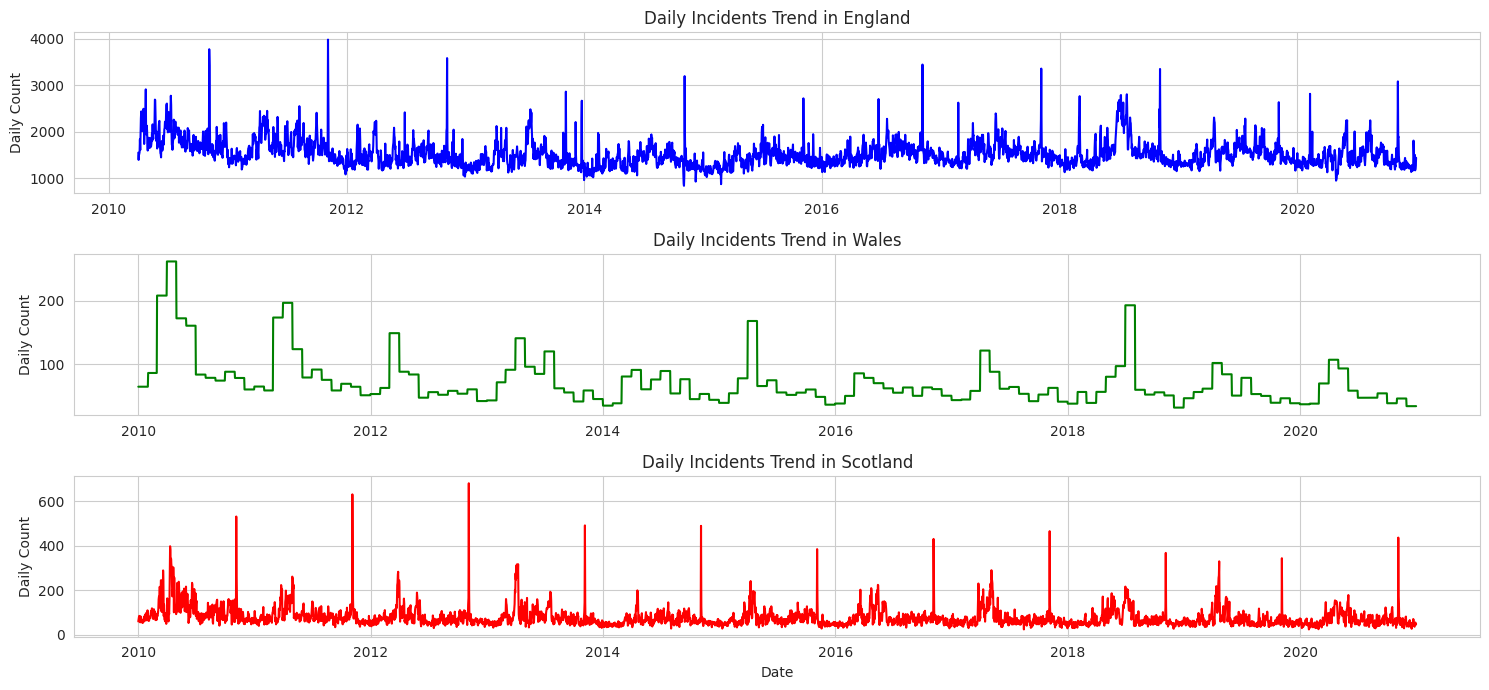

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'date' column is in datetime format
df['date'] = pd.to_datetime(df['date'])

# Filter data for each country
england_data = df[df['country'] == 'England']
wales_data = df[df['country'] == 'Wales']
scotland_data = df[df['country'] == 'Scotland']

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

plt.figure(figsize=(15, 7))

# Plot for England
plt.subplot(3, 1, 1) # 3 rows, 1 column, 1st plot
sns.lineplot(x='date', y='daily_count', data=england_data, color='blue')
plt.title('Daily Incidents Trend in England')
plt.xlabel('')
plt.ylabel('Daily Count')

# Plot for Wales
plt.subplot(3, 1, 2) # 3 rows, 1 column, 2nd plot
sns.lineplot(x='date', y='daily_count', data=wales_data, color='green')
plt.title('Daily Incidents Trend in Wales')
plt.xlabel('')
plt.ylabel('Daily Count')

# Plot for Scotland
plt.subplot(3, 1, 3) # 3 rows, 1 column, 3rd plot
sns.lineplot(x='date', y='daily_count', data=scotland_data, color='red')
plt.title('Daily Incidents Trend in Scotland')
plt.xlabel('Date')
plt.ylabel('Daily Count')

plt.tight_layout()
plt.show()

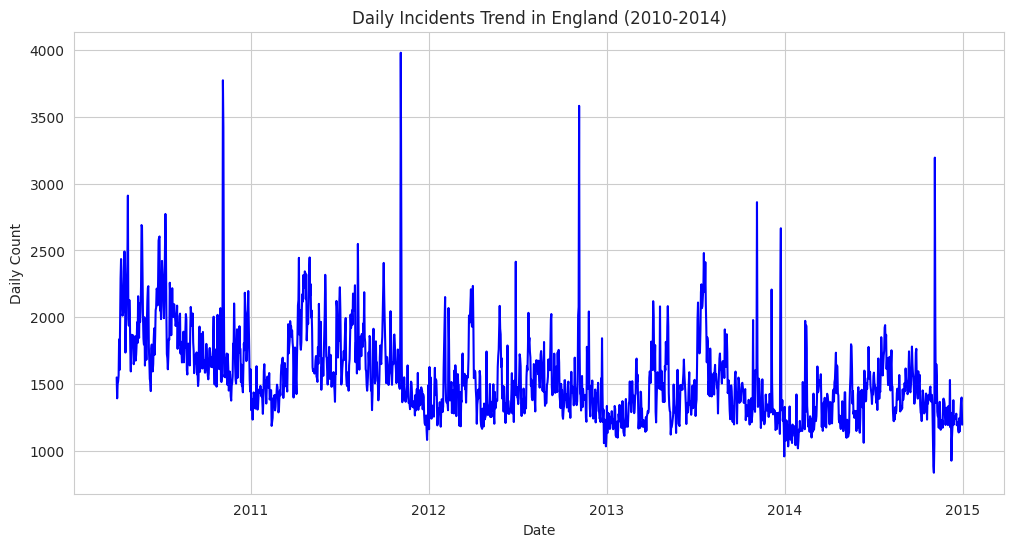


Average number of daily incidents for January, February, and March (2011-2014):
   Year  Average Daily Incidents (Jan-Mar)
0  2011                        1498.166667
1  2012                        1502.450549
2  2013                        1289.544444
3  2014                        1264.377778


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'date' column is in datetime format (if not already)
# df['date'] = pd.to_datetime(df['date'])

# Filter data for England (assuming 'england_data' is already defined from previous cells)
# If 'england_data' is not available, uncomment and run the following line:
# england_data = df[df['country'] == 'England'].copy()

# --- Part 1: Plot for England time series data from 2010 to 2014 ---

# Filter England data for the period 2010-2014
england_2010_2014 = england_data[(england_data['date'].dt.year >= 2010) & (england_data['date'].dt.year <= 2014)]

plt.figure(figsize=(12, 6))
sns.lineplot(x='date', y='daily_count', data=england_2010_2014, color='blue')
plt.title('Daily Incidents Trend in England (2010-2014)')
plt.xlabel('Date')
plt.ylabel('Daily Count')
plt.grid(True)
plt.show()

# --- Part 2: Average incidents for Jan, Feb, March (2011-2014) ---

# Filter data for the specified years (2011-2014)
filtered_years_data = england_data[(england_data['date'].dt.year >= 2011) & (england_data['date'].dt.year <= 2014)]

# Filter for months January (1), February (2), and March (3)
filtered_months_data = filtered_years_data[filtered_years_data['date'].dt.month.isin([1, 2, 3])]

# Calculate the average daily incidents for these months, grouped by year
average_incidents = filtered_months_data.groupby(filtered_months_data['date'].dt.year)['daily_count'].mean().reset_index()
average_incidents.columns = ['Year', 'Average Daily Incidents (Jan-Mar)']

print("\nAverage number of daily incidents for January, February, and March (2011-2014):")
print(average_incidents)


In [7]:
# Part 1: Average daily incidents by month for England for 2010 (Apr-Dec)
print("\nAverage daily incidents for England (2010, April-December):")
england_2010_aprtodec = england_data[
    (england_data['date'].dt.year == 2010) &
    (england_data['date'].dt.month >= 4) &
    (england_data['date'].dt.month <= 12)
]

average_2010_aprtodec_by_month = england_2010_aprtodec.groupby(england_2010_aprtodec['date'].dt.month)['daily_count'].mean().reset_index()
average_2010_aprtodec_by_month.columns = ['Month', 'Average Daily Incidents']
# Map month numbers to names for better readability
month_names = {i: pd.to_datetime(f'2000-{i}-01').strftime('%b') for i in range(1, 13)}
average_2010_aprtodec_by_month['Month'] = average_2010_aprtodec_by_month['Month'].map(month_names)
print(average_2010_aprtodec_by_month)

# Part 2: Table of JAN, FEB, and MAR averages from 2011, 2012, 2013, and 2014
print("\nAverage daily incidents for England (Jan, Feb, Mar for 2011-2014):")
filtered_janfebmar_data = england_data[
    (england_data['date'].dt.year.isin([2011, 2012, 2013, 2014])) &
    (england_data['date'].dt.month.isin([1, 2, 3]))
].copy()

# Create a month name column for better readability in the pivot table
filtered_janfebmar_data['Month'] = filtered_janfebmar_data['date'].dt.strftime('%b')

# Calculate monthly averages grouped by year and month
monthly_avg_incidents = filtered_janfebmar_data.groupby([
    filtered_janfebmar_data['date'].dt.year,
    'Month'
])['daily_count'].mean().unstack(level='Month')

# Reorder columns to ensure Jan, Feb, Mar order
monthly_avg_incidents = monthly_avg_incidents[['Jan', 'Feb', 'Mar']]
monthly_avg_incidents.index.name = 'Year'
monthly_avg_incidents.columns.name = None # Remove column name for aesthetics
print(monthly_avg_incidents)


Average daily incidents for England (2010, April-December):
  Month  Average Daily Incidents
0   Apr              2008.500000
1   May              1932.967742
2   Jun              1962.300000
3   Jul              2081.838710
4   Aug              1829.935484
5   Sep              1730.833333
6   Oct              1716.161290
7   Nov              1764.266667
8   Dec              1746.645161

Average daily incidents for England (Jan, Feb, Mar for 2011-2014):
              Jan          Feb          Mar
Year                                       
2011  1424.870968  1405.392857  1655.258065
2012  1356.677419  1527.586207  1624.709677
2013  1223.032258  1306.357143  1340.870968
2014  1150.032258  1292.571429  1353.258065


In [8]:
# Part 1: Average daily incidents by month for England for 2010 (Apr-Dec)
print("\nAverage daily incidents for England (2010, April-December):")
england_2010_aprtodec = england_data[
    (england_data['date'].dt.year == 2010) &
    (england_data['date'].dt.month >= 4) &
    (england_data['date'].dt.month <= 12)
]

average_2010_aprtodec_by_month = england_2010_aprtodec.groupby(england_2010_aprtodec['date'].dt.month)['daily_count'].mean().reset_index()
average_2010_aprtodec_by_month.columns = ['Month', 'Average Daily Incidents']
# Map month numbers to names for better readability
month_names = {i: pd.to_datetime(f'2000-{i}-01').strftime('%b') for i in range(1, 13)}
average_2010_aprtodec_by_month['Month'] = average_2010_aprtodec_by_month['Month'].map(month_names)
print(average_2010_aprtodec_by_month)

# Part 2: Table of JAN, FEB, and MAR averages from 2011, 2012, 2013, and 2014
print("\nAverage daily incidents for England (Jan, Feb, Mar for 2011-2014):")
filtered_janfebmar_data = england_data[
    (england_data['date'].dt.year.isin([2011, 2012, 2013, 2014])) &
    (england_data['date'].dt.month.isin([1, 2, 3]))
].copy()

# Create a month name column for better readability in the pivot table
filtered_janfebmar_data['Month'] = filtered_janfebmar_data['date'].dt.strftime('%b')

# Calculate monthly averages grouped by year and month
monthly_avg_incidents = filtered_janfebmar_data.groupby([
    filtered_janfebmar_data['date'].dt.year,
    'Month'
])['daily_count'].mean().unstack(level='Month')

# Reorder columns to ensure Jan, Feb, Mar order
monthly_avg_incidents = monthly_avg_incidents[['Jan', 'Feb', 'Mar']]
monthly_avg_incidents.index.name = 'Year'
monthly_avg_incidents.columns.name = None # Remove column name for aesthetics
print(monthly_avg_incidents)


Average daily incidents for England (2010, April-December):
  Month  Average Daily Incidents
0   Apr              2008.500000
1   May              1932.967742
2   Jun              1962.300000
3   Jul              2081.838710
4   Aug              1829.935484
5   Sep              1730.833333
6   Oct              1716.161290
7   Nov              1764.266667
8   Dec              1746.645161

Average daily incidents for England (Jan, Feb, Mar for 2011-2014):
              Jan          Feb          Mar
Year                                       
2011  1424.870968  1405.392857  1655.258065
2012  1356.677419  1527.586207  1624.709677
2013  1223.032258  1306.357143  1340.870968
2014  1150.032258  1292.571429  1353.258065


In [11]:
england_df = df[df['country'] == 'England'].copy()

In [12]:
full_date_range = pd.date_range(
    start=df["date"].min(),   # <-- Max date from date range of whole dataframe
    end=df["date"].max(),     # <-- min from date range of whole dataframe
    freq="D"
)

FInd missing dates

In [13]:
existing_england_dates = set(england_df["date"])
missing_dates = [d for d in full_date_range if d not in existing_england_dates]

print(f"Number of missing dates: {len(missing_dates)}")
print(missing_dates)

Number of missing dates: 90
[Timestamp('2010-01-01 00:00:00'), Timestamp('2010-01-02 00:00:00'), Timestamp('2010-01-03 00:00:00'), Timestamp('2010-01-04 00:00:00'), Timestamp('2010-01-05 00:00:00'), Timestamp('2010-01-06 00:00:00'), Timestamp('2010-01-07 00:00:00'), Timestamp('2010-01-08 00:00:00'), Timestamp('2010-01-09 00:00:00'), Timestamp('2010-01-10 00:00:00'), Timestamp('2010-01-11 00:00:00'), Timestamp('2010-01-12 00:00:00'), Timestamp('2010-01-13 00:00:00'), Timestamp('2010-01-14 00:00:00'), Timestamp('2010-01-15 00:00:00'), Timestamp('2010-01-16 00:00:00'), Timestamp('2010-01-17 00:00:00'), Timestamp('2010-01-18 00:00:00'), Timestamp('2010-01-19 00:00:00'), Timestamp('2010-01-20 00:00:00'), Timestamp('2010-01-21 00:00:00'), Timestamp('2010-01-22 00:00:00'), Timestamp('2010-01-23 00:00:00'), Timestamp('2010-01-24 00:00:00'), Timestamp('2010-01-25 00:00:00'), Timestamp('2010-01-26 00:00:00'), Timestamp('2010-01-27 00:00:00'), Timestamp('2010-01-28 00:00:00'), Timestamp('2010-01-

In [14]:
print("Total unique dates in dataset :", df["date"].nunique())
print("Total unique dates for England:", england_df["date"].nunique())
print("Total missing dates for England:", df["date"].nunique() - england_df["date"].nunique() )

Total unique dates in dataset : 4018
Total unique dates for England: 3928
Total missing dates for England: 90


In [15]:
# Ensure 'england_data' is available. If not, uncomment the line below:
# england_data = df[df['country'] == 'England'].copy()

# Filter data for England, years 2011-2014, and months Jan, Feb, Mar
filtered_data = england_data[
    (england_data['date'].dt.year.isin([2011, 2012, 2013, 2014])) &
    (england_data['date'].dt.month.isin([1, 2, 3]))
].copy()

# Create a month column for grouping
filtered_data['month'] = filtered_data['date'].dt.month_name().str[:3] # Jan, Feb, Mar

# Calculate yearly monthly averages and display them
yearly_monthly_averages = filtered_data.groupby(['date' , 'month'])['daily_count'].mean().reset_index()
yearly_monthly_averages = filtered_data.groupby([filtered_data['date'].dt.year, 'month'])['daily_count'].mean().unstack(level='month')

# Reorder columns to ensure Jan, Feb, Mar order
yearly_monthly_averages = yearly_monthly_averages[['Jan', 'Feb', 'Mar']]
yearly_monthly_averages.index.name = 'Year'
yearly_monthly_averages.columns.name = 'Month'

print("Average fire incidents for Jan, Feb, Mar (2011-2014) by Year:")
print(yearly_monthly_averages)
print("\n")

# Calculate the overall average for each month across the years 2011-2014
Jan_avg_11_14 = yearly_monthly_averages['Jan'].mean()
Feb_avg_11_14 = yearly_monthly_averages['Feb'].mean()
Mar_avg_11_14 = yearly_monthly_averages['Mar'].mean()

# Display the overall averages
print(f"Overall Average for January (2011-2014): {Jan_avg_11_14:.2f}")
print(f"Overall Average for February (2011-2014): {Feb_avg_11_14:.2f}")
print(f"Overall Average for March (2011-2014): {Mar_avg_11_14:.2f}")

Average fire incidents for Jan, Feb, Mar (2011-2014) by Year:
Month          Jan          Feb          Mar
Year                                        
2011   1424.870968  1405.392857  1655.258065
2012   1356.677419  1527.586207  1624.709677
2013   1223.032258  1306.357143  1340.870968
2014   1150.032258  1292.571429  1353.258065


Overall Average for January (2011-2014): 1288.65
Overall Average for February (2011-2014): 1382.98
Overall Average for March (2011-2014): 1493.52


In [17]:
# Make a copy of the main dataframe to work with
df_combined = df.copy()

# Prepare new rows for missing England data in Jan, Feb, Mar 2010
new_england_rows = []
for m_date in missing_dates:
    month = m_date.month
    if month == 1: # January
        avg_value = Jan_avg_11_14
    elif month == 2: # February
        avg_value = Feb_avg_11_14
    elif month == 3: # March
        avg_value = Mar_avg_11_14
    else:
        # This should not happen if missing_dates only contains Jan-Mar 2010
        continue

    new_england_rows.append({'date': m_date, 'country': 'England', 'daily_count': avg_value})

# Create a DataFrame from the new rows
df_new_england = pd.DataFrame(new_england_rows)

# Concatenate the new England data with the combined dataframe
df_combined = pd.concat([df_combined, df_new_england], ignore_index=True)

# Sort the dataframe by date and country to ensure correct order after adding new rows
df_combined = df_combined.sort_values(by=['date', 'country']).reset_index(drop=True)

# Round the 'daily_count' column to two decimal places
df_combined['daily_count'] = df_combined['daily_count'].round(2)

# Save the final dataframe to Google Drive
output_path = '/content/drive/MyDrive/Combined_data_fire_final.csv'
df_combined.to_csv(output_path, index=False)

print(f"Combined data with imputed England values saved to: {output_path}")
print("First 5 rows of the combined dataframe:")
print(df_combined.head())
print("Last 5 rows of the combined dataframe:")
print(df_combined.tail())

Combined data with imputed England values saved to: /content/drive/MyDrive/Combined_data_fire_final.csv
First 5 rows of the combined dataframe:
        date   country  daily_count
0 2010-01-01   England      1288.65
1 2010-01-01  Scotland        59.00
2 2010-01-01     Wales        65.10
3 2010-01-02   England      1288.65
4 2010-01-02  Scotland        69.00
Last 5 rows of the combined dataframe:
            date   country  daily_count
12049 2020-12-30  Scotland        44.00
12050 2020-12-30     Wales        34.58
12051 2020-12-31   England      1441.00
12052 2020-12-31  Scotland        47.00
12053 2020-12-31     Wales        34.58
